<a href="https://colab.research.google.com/github/nicolasspaniol/deep-learning-pa1/blob/main/notebooks/part0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import random
import torch
from torch.utils.data import Dataset

class SyntheticEllipseDataset(Dataset):
    def __init__(self, num_samples=500, img_size=128):
        self.num_samples = num_samples
        self.img_size = img_size

    def __len__(self):
        return self.num_samples

    def _generate_sample(self):
        size = self.img_size
        img = np.ones((size, size, 3), dtype=np.uint8) * 255
        mask = np.zeros((size, size), dtype=np.uint8)
        instance_mask = np.zeros((size, size), dtype=np.int32)  # para instâncias

        num_ellipses = random.randint(5, 20)
        for i in range(num_ellipses):
            center = (random.randint(10, size-10), random.randint(10, size-10))
            axes = (random.randint(5, 25), random.randint(5, 25))
            angle = random.randint(0, 180)
            gray = random.randint(30, 180)  # contraste variável

            cv2.ellipse(img, center, axes, angle, 0, 360, (gray, gray, gray), -1)
            cv2.ellipse(mask, center, axes, angle, 0, 360, 255, -1)
            cv2.ellipse(instance_mask, center, axes, angle, 0, 360, i+1, -1)  # id único

        # Ruído gaussiano
        noise = np.random.normal(0, 15, img.shape)
        img = np.clip(img + noise, 0, 255).astype(np.uint8)

        return img, mask, instance_mask

    def __getitem__(self, idx):
        img, mask, instance_mask = self._generate_sample()

        # Converter para tensores (C, H, W)
        img_t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        mask_t = torch.from_numpy(mask).float() / 255.0
        instance_t = torch.from_numpy(instance_mask).long()

        return img_t, mask_t, instance_t


# Uso:
dataset = SyntheticEllipseDataset(num_samples=500)
from torch.utils.data import DataLoader
loader = DataLoader(dataset, batch_size=16, shuffle=True)

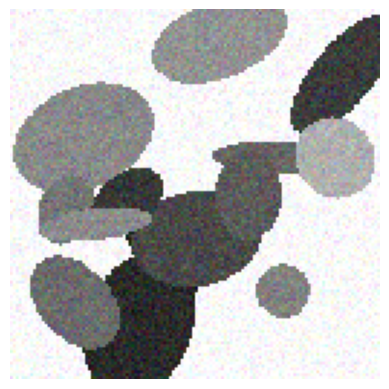

In [5]:
import matplotlib.pyplot as plt

imgs, masks, insts = next(iter(loader))

plt.imshow(imgs[0].permute(1, 2, 0))
plt.axis('off')
plt.show()
